<a href="https://colab.research.google.com/github/matheuspaleari/Engenharia-de-dados/blob/main/pipeline_vendas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Nova seção

In [ ]:
### Importar base de dados "vendas.csv"
from google.colab import files

csv = files.upload()

Saving vendas.csv to vendas (3).csv


In [ ]:
### Leitura dos dados.
import pandas as pd

df = pd.read_csv('vendas.csv')

df.head()

,id,produto,categoria,valor,quantidade,data,cidade
0,1,Notebook,Eletronicos,3500,1,2026-01-10,Sao Paulo
1,2,Mouse,Eletronicos,120,2,2026-01-11,Campinas
2,3,Teclado,Eletronicos,250,1,2026-01-11,Paulinia
3,4,Cadeira Gamer,Moveis,1500,1,2026-01-12,Sumare
4,5,Monitor,Eletronicos,900,2,2026-01-12,Campinas


In [ ]:
### Transformação ETL
df['data'] = pd.to_datetime(df['data'])

df['valor_total'] = df['valor'] * df['quantidade']

df['mes'] = df['data'].dt.month

df.head()

,id,produto,categoria,valor,quantidade,data,cidade,valor_total,mes
0,1,Notebook,Eletronicos,3500,1,2026-01-10,Sao Paulo,3500,1
1,2,Mouse,Eletronicos,120,2,2026-01-11,Campinas,240,1
2,3,Teclado,Eletronicos,250,1,2026-01-11,Paulinia,250,1
3,4,Cadeira Gamer,Moveis,1500,1,2026-01-12,Sumare,1500,1
4,5,Monitor,Eletronicos,900,2,2026-01-12,Campinas,1800,1


In [ ]:
### Salvar em banco SQL
import sqlite3

conn = sqlite3.connect('vendas.db')

df.to_sql(
    'vendas_tratadas',
    conn,
    if_exists='replace',
    index=False
)

20

In [ ]:
### Fazer consultas simples SQL
query = """
SELECT categoria,
       SUM(valor_total) AS faturamento
FROM vendas_tratadas
GROUP BY categoria
"""

resultado = pd.read_sql(query, conn)

print(resultado)

     categoria  faturamento
0   Acessorios          670
1  Eletronicos        21640
2       Moveis         4690


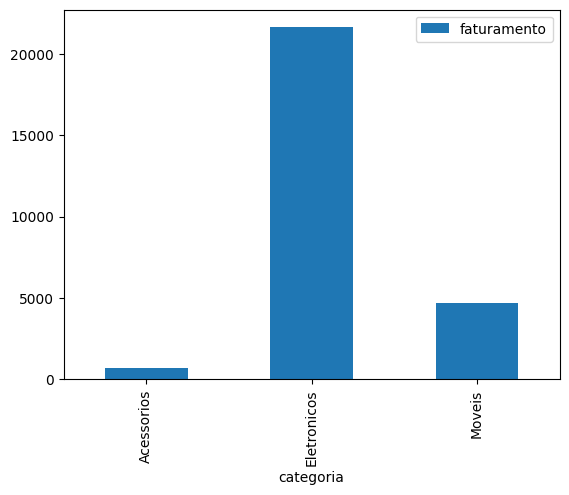

In [ ]:
### Gerar gráfico
import matplotlib.pyplot as plt

resultado.plot(
    x='categoria',
    y='faturamento',
    kind='bar'
)

plt.show()

In [ ]:
print("Faturamento Total:", df['valor_total'].sum())

print("Quantidade de vendas:", len(df))

Faturamento Total: 27000
Quantidade de vendas: 20
